# GSE250346 (Dataset 01) — load & explore TMA5 SpatialData

GEO human lung Xenium TMA data ([GSE250346](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE250346)).

This notebook loads the companion **TMA5.zarr** SpatialData store and inspects its elements (images, labels, shapes, transcript points, cell table). For AnnData/h5ad exploration see [`01_celltypeing_compare.ipynb`](01_celltypeing_compare.ipynb).

> **Note:** `TMA5.zarr` uses Zarr v3 (SpatialData 0.7.2). Requires Python ≥3.11 and spatialdata ≥0.7.2.

**Kernel:** `spatialdata`

In [7]:
from pathlib import Path
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # registers .pl accessor
import sys
sys.path.append("/mnt/scratch2/Maycon/Utils/py_codabase")
import Utils
import pandas as pd



In [4]:
adata = ad.read_h5ad("/mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_01/processed_data/one_sample.h5ad")

In [5]:
# Sanity check: .X should hold integer transcript counts
x = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
assert x.min() >= 0, f"Expected nonnegative counts, got min={x.min()}"
assert np.allclose(x.sum(axis=1), adata.obs["nCount"], rtol=1e-4), "X row sums must match nCount"
print(f"X holds integer transcript counts (min={x.min():.0f}, max={x.max():.0f})")
print(f"Row-sum check vs nCount: OK ({adata.n_obs:,} cells)")

X holds integer transcript counts (min=0, max=178)
Row-sum check vs nCount: OK (27,791 cells)


## 2. Approach i — scanpy clustering + manual annotation

Standard scanpy workflow on `adata`. After marker tables render, update `CLUSTER_ANNOTATIONS` below.

In [ ]:
SCANPY_CFG = {
    "n_pcs": 30,
    "n_neighbors": 15,
    "leiden_resolution": 0.5,
    "rank_genes_top_n": 20,
    "seed": 42,
}

adata_sc = adata.copy()

# Targeted 343-gene panel: use all genes (no HVG subset)
sc.pp.normalize_total(adata_sc, target_sum=1e4)
sc.pp.log1p(adata_sc)
sc.pp.scale(adata_sc, max_value=10)

n_comps = min(SCANPY_CFG["n_pcs"], adata_sc.n_obs - 1, adata_sc.n_vars - 1)
sc.tl.pca(adata_sc, n_comps=n_comps, random_state=SCANPY_CFG["seed"])
sc.pp.neighbors(adata_sc, n_neighbors=SCANPY_CFG["n_neighbors"])
sc.tl.leiden(
    adata_sc,
    resolution=SCANPY_CFG["leiden_resolution"],
    key_added="leiden",
    random_state=SCANPY_CFG["seed"],
)
sc.tl.umap(adata_sc, random_state=SCANPY_CFG["seed"])

# Copy results back to adata (single object used throughout)
adata.obs["leiden"] = adata_sc.obs["leiden"].astype(str)
adata.obsm["X_umap"] = adata_sc.obsm["X_umap"]
adata.uns["rank_genes_groups"] = adata_sc.uns["rank_genes_groups"]


/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


KeyboardInterrupt: 

In [ ]:
adata_sc = adata.copy()
# Targeted 343-gene panel: use all genes (no HVG subset)
sc.pp.normalize_total(adata_sc, target_sum=1e4)
sc.pp.log1p(adata_sc)
sc.tl.rank_genes_groups(adata_sc, groupby="leiden", method="wilcoxon", use_raw=False)
adata.uns["rank_genes_groups"] = adata_sc.uns["rank_genes_groups"]



/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


,cluster,names,scores,logfoldchanges,pvals,pvals_adj
0,0,FN1,79.207222,3.915957,0.000000e+00,0.000000e+00
1,0,LUM,78.696281,5.100549,0.000000e+00,0.000000e+00
2,0,COL1A1,72.777214,5.245815,0.000000e+00,0.000000e+00
3,0,COL1A2,69.432350,4.307420,0.000000e+00,0.000000e+00
4,0,PTGDS,69.257645,4.322383,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...
155,15,DNAJB9,19.714996,5.356322,1.603272e-86,9.165370e-85
156,15,PRDX4,19.298727,5.491422,5.504961e-83,2.697431e-81
157,15,HSPA5,18.869833,4.054626,2.019346e-79,8.657946e-78
158,15,PIM2,18.261526,6.389452,1.675429e-74,6.385247e-73


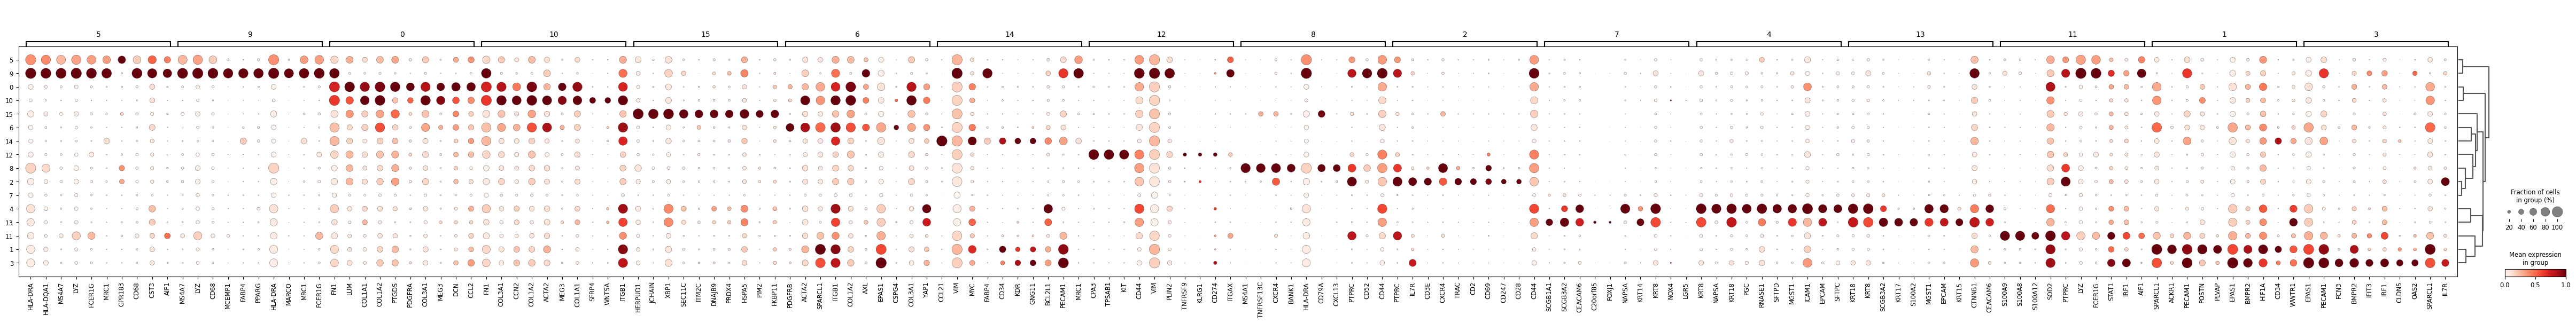

In [14]:
#top_n = SCANPY_CFG["rank_genes_top_n"]
top_n = 10
clusters = sorted(adata.obs["leiden"].unique(), key=lambda x: int(x))

marker_tables = []
for cluster in clusters:
    df = sc.get.rank_genes_groups_df(adata, group=cluster)
    df = df.head(top_n).copy()
    df.insert(0, "cluster", cluster)
    marker_tables.append(df)

markers_top20 = pd.concat(marker_tables, ignore_index=True)
display(markers_top20)

sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=top_n,
    groupby="leiden",
    standard_scale="var",
    show=False,
)
plt.show()

In [16]:
marker_dict = (
    markers_top20
    .groupby("cluster", sort=False)["names"]
    .apply(list)
    .to_dict()
)

marker_dict

{'0': ['FN1',
  'LUM',
  'COL1A1',
  'COL1A2',
  'PTGDS',
  'PDGFRA',
  'COL3A1',
  'MEG3',
  'DCN',
  'CCL2'],
 '1': ['SPARCL1',
  'ACKR1',
  'PECAM1',
  'POSTN',
  'PLVAP',
  'EPAS1',
  'BMPR2',
  'HIF1A',
  'CD34',
  'WWTR1'],
 '2': ['PTPRC',
  'IL7R',
  'CD3E',
  'CXCR4',
  'TRAC',
  'CD2',
  'CD69',
  'CD247',
  'CD28',
  'CD44'],
 '3': ['EPAS1',
  'PECAM1',
  'FCN3',
  'BMPR2',
  'IFIT3',
  'IRF1',
  'CLDN5',
  'OAS2',
  'SPARCL1',
  'IL7R'],
 '4': ['KRT8',
  'NAPSA',
  'KRT18',
  'PGC',
  'RNASE1',
  'SFTPD',
  'MGST1',
  'ICAM1',
  'EPCAM',
  'SFTPC'],
 '5': ['HLA-DRA',
  'HLA-DQA1',
  'MS4A7',
  'LYZ',
  'FCER1G',
  'MRC1',
  'GPR183',
  'CD68',
  'CST3',
  'AIF1'],
 '6': ['PDGFRB',
  'ACTA2',
  'SPARCL1',
  'ITGB1',
  'COL1A2',
  'AXL',
  'EPAS1',
  'CSPG4',
  'COL3A1',
  'YAP1'],
 '7': ['SCGB1A1',
  'SCGB3A2',
  'CEACAM6',
  'C20orf85',
  'FOXJ1',
  'NAPSA',
  'KRT14',
  'KRT8',
  'NOX4',
  'LGR5'],
 '8': ['MS4A1',
  'TNFRSF13C',
  'CXCR4',
  'BANK1',
  'HLA-DRA',
  'CD79A',

In [17]:
# Update this dict after reviewing the marker tables above.
# Keys are Leiden cluster IDs (strings). Unmapped clusters become "Unassigned".
CLUSTER_ANNOTATIONS = {
    "0":  "Fibroblast",
    "1":  "Endothelial",
    "2":  "T cell",
    "3":  "Endothelial",
    "4":  "Alveolar epithelial",
    "5":  "Macrophage",
    "6":  "Pericyte",
    "7":  "Airway epithelial",
    "8":  "B cell",
    "9":  "Alveolar macrophage",
    "10": "Myofibroblast",
    "11": "Inflammatory myeloid",
    "12": "Mast cell",
    "13": "Basal epithelial",
    "14": "Lymphatic endothelial",
    "15": "Plasma cell",
}

adata.obs["cell_type_scanpy"] = (
    adata.obs["leiden"]
    .astype(str)
    .map(CLUSTER_ANNOTATIONS)
    .fillna("Unassigned")
)

adata.obs["cell_type_scanpy"] = adata.obs["cell_type_scanpy"].astype("category")

display(
    adata.obs["cell_type_scanpy"].value_counts(dropna=False)
)

cell_type_scanpy
Endothelial              5253
Fibroblast               4877
T cell                   2709
Alveolar epithelial      2269
Macrophage               2264
Pericyte                 2004
Airway epithelial        1577
B cell                   1360
Alveolar macrophage      1256
Myofibroblast            1113
Inflammatory myeloid     1045
Mast cell                 955
Basal epithelial          410
Lymphatic endothelial     358
Plasma cell               341
Name: count, dtype: int64

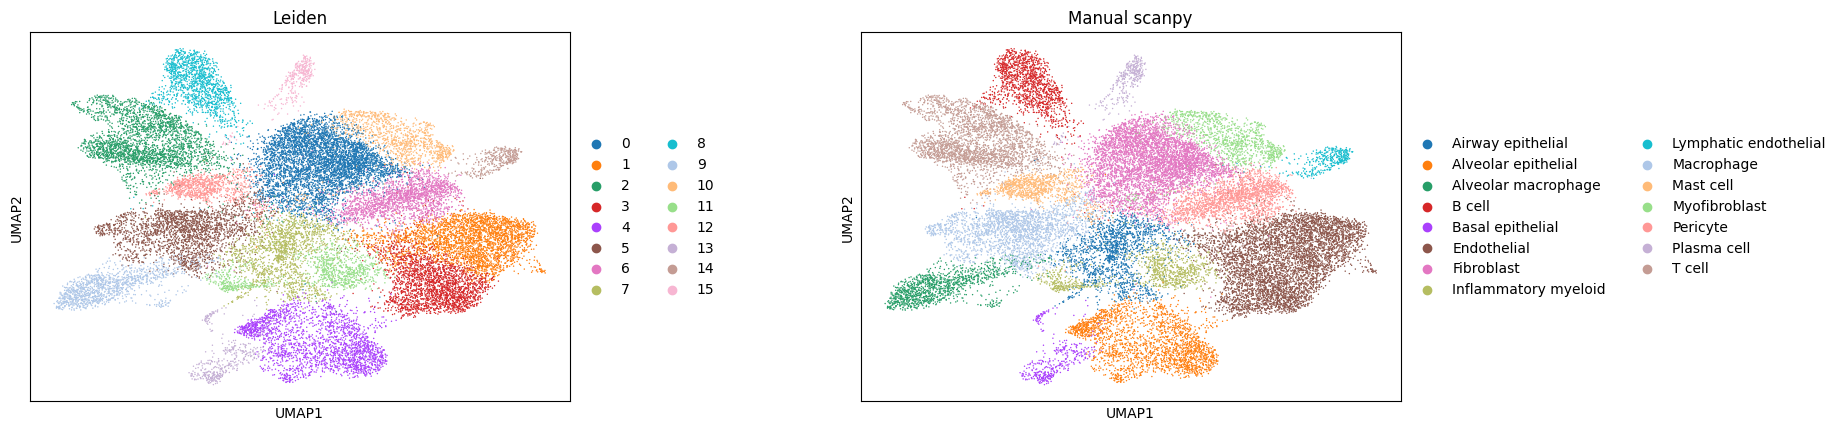

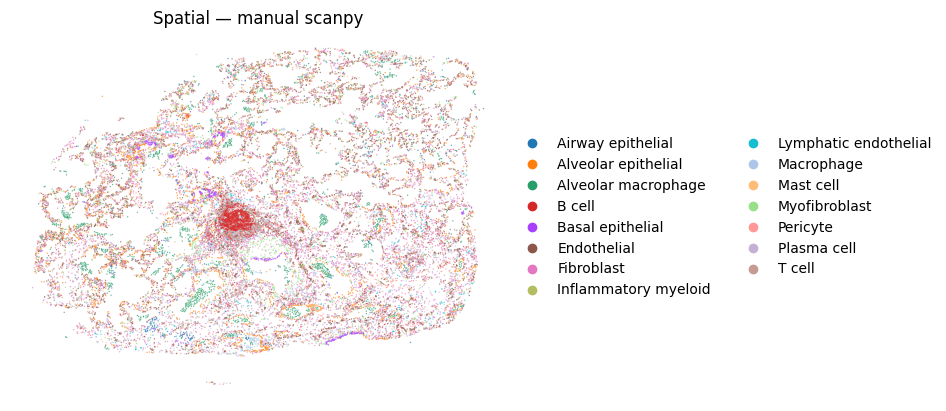

In [18]:
sc.pl.umap(
    adata,
    color=["leiden", "cell_type_scanpy"],
    wspace=0.4,
    title=[f"Leiden", f"Manual scanpy"],
)

Utils.SpatialCoord_plot(
    adata,
    variable="cell_type_scanpy",
    size=4,
    alpha=0.7,
    title=f"Spatial — manual scanpy",
)

## 3. Approach ii — rule-based epithelial / B-cell typing

Pick the 4 most frequently detected epithelial and B-cell markers in this sample, then assign a label only when **all 4 panel genes have raw count > 0**.

In [20]:
EPI_CANDIDATES = [
    "EPCAM", "KRT8", "KRT18", "KRT19", "SFTPC", "SFTPB",
    "SFTPA1", "SLC34A2", "AGER", "NAPSA",
]
BCELL_CANDIDATES = [
    "CD79A", "MS4A1", "CD79B", "CD19", "CD22",
    "BANK1", "CD37", "CD74",
]


def detection_rate(adata, genes):
    """Fraction of cells with raw count > 0 for each gene in adata."""
    present = [g for g in genes if g in adata.var_names]
    rates = {}
    for gene in present:
        x = adata[:, gene].X
        if hasattr(x, "toarray"):
            x = x.toarray().ravel()
        else:
            x = np.asarray(x).ravel()
        rates[gene] = float((x > 0).mean())
    return pd.Series(rates).sort_values(ascending=False)


epi_rates = detection_rate(adata, EPI_CANDIDATES)
bcell_rates = detection_rate(adata, BCELL_CANDIDATES)

EPI_MARKERS = epi_rates.head(4).index.tolist()
BCELL_MARKERS = bcell_rates.head(4).index.tolist()

print(f"Selected epithelial markers:")
display(epi_rates.head(4))
print(f"\nSelected B-cell markers:")
display(bcell_rates.head(4))
print(f"\nEPI_MARKERS  = {EPI_MARKERS}")
print(f"BCELL_MARKERS = {BCELL_MARKERS}")

Selected epithelial markers:


KRT8     0.256270
KRT18    0.222626
SFTPC    0.173078
NAPSA    0.133317
dtype: float64


Selected B-cell markers:


BANK1    0.059372
MS4A1    0.053219
CD79A    0.047713
CD19     0.022813
dtype: float64


EPI_MARKERS  = ['KRT8', 'KRT18', 'SFTPC', 'NAPSA']
BCELL_MARKERS = ['BANK1', 'MS4A1', 'CD79A', 'CD19']


In [21]:
def _get_gene_counts(adata, genes):
    """Return (n_cells, n_genes) array of integer transcript counts from .X."""
    x = adata[:, genes].X
    if hasattr(x, "toarray"):
        return x.toarray()
    return np.asarray(x)


def assign_rule_labels(adata, genes_epi, genes_bcell):
    """Assign labels when all 4 genes in a panel have count > 0."""
    epi_x = _get_gene_counts(adata, genes_epi)
    bcell_x = _get_gene_counts(adata, genes_bcell)

    epi_pos = (epi_x > 0).all(axis=1)
    bcell_pos = (bcell_x > 0).all(axis=1)

    labels = np.full(adata.n_obs, "Unassigned", dtype=object)
    labels[epi_pos & ~bcell_pos] = "Epithelial"
    labels[~epi_pos & bcell_pos] = "B cells"
    labels[epi_pos & bcell_pos] = "Ambiguous"
    return labels


adata.obs["cell_type_rule"] = pd.Categorical(
    assign_rule_labels(adata, EPI_MARKERS, BCELL_MARKERS)
)

print(f"Rule-based labels")
display(adata.obs["cell_type_rule"].value_counts())

Rule-based labels


cell_type_rule
Unassigned    26038
Epithelial     1481
B cells         272
Name: count, dtype: int64

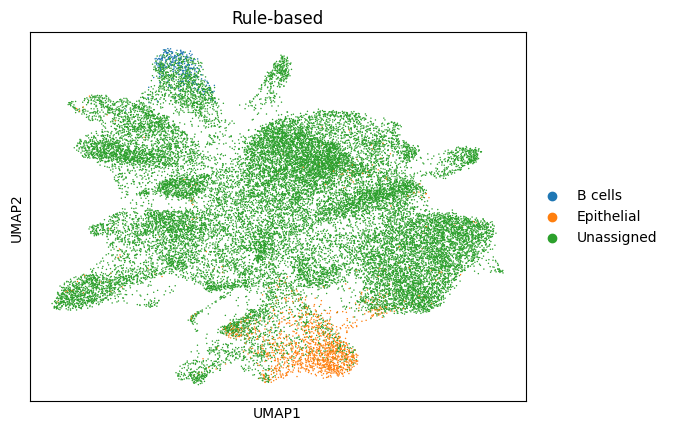

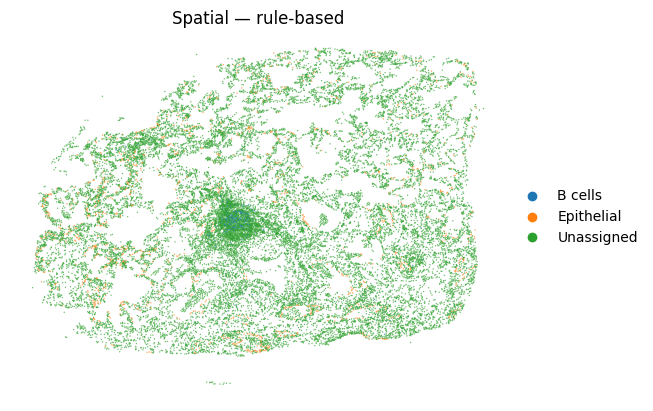

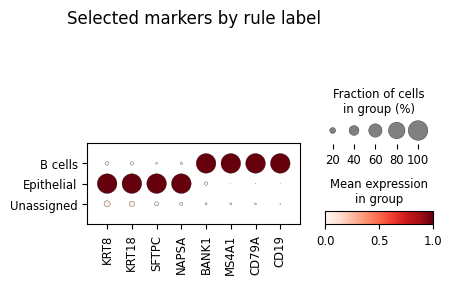

In [22]:
sc.pl.umap(
    adata,
    color="cell_type_rule",
    title=f"Rule-based",
)

Utils.SpatialCoord_plot(
    adata,
    variable="cell_type_rule",
    size=4,
    alpha=0.7,
    title=f"Spatial — rule-based",
)

sc.pl.dotplot(
    adata,
    var_names=EPI_MARKERS + BCELL_MARKERS,
    groupby="cell_type_rule",
    standard_scale="var",
    title=f"Selected markers by rule label",
)

## 4. Compare categories: scanpy (i) vs rule-based (ii)

In [23]:
print(f"Comparison for sample:\n")

print("=== Counts ===")
summary = pd.DataFrame({
    "cell_type_scanpy": adata.obs["cell_type_scanpy"].value_counts(),
    "cell_type_rule": adata.obs["cell_type_rule"].value_counts(),
})
display(summary)

print("\n=== Crosstab (scanpy rows × rule cols) ===")
ct = pd.crosstab(
    adata.obs["cell_type_scanpy"],
    adata.obs["cell_type_rule"],
    margins=True,
)
display(ct)

print("\n=== Row-normalized crosstab ===")
ct_norm = pd.crosstab(
    adata.obs["cell_type_scanpy"],
    adata.obs["cell_type_rule"],
    normalize="index",
).round(3)
display(ct_norm)

Comparison for sample:

=== Counts ===


,cell_type_scanpy,cell_type_rule
Airway epithelial,1577.0,NaN
Alveolar epithelial,2269.0,NaN
Alveolar macrophage,1256.0,NaN
B cell,1360.0,NaN
B cells,NaN,272.0
Basal epithelial,410.0,NaN
Endothelial,5253.0,NaN
Epithelial,NaN,1481.0
Fibroblast,4877.0,NaN
Inflammatory myeloid,1045.0,NaN



=== Crosstab (scanpy rows × rule cols) ===


cell_type_rule,B cells,Epithelial,Unassigned,All
cell_type_scanpy,,,,
Airway epithelial,0,26,1551,1577
Alveolar epithelial,0,1263,1006,2269
Alveolar macrophage,0,17,1239,1256
B cell,271,0,1089,1360
Basal epithelial,0,11,399,410
Endothelial,0,91,5162,5253
Fibroblast,0,27,4850,4877
Inflammatory myeloid,0,3,1042,1045
Lymphatic endothelial,0,0,358,358



=== Row-normalized crosstab ===


cell_type_rule,B cells,Epithelial,Unassigned
cell_type_scanpy,,,
Airway epithelial,0.000,0.016,0.984
Alveolar epithelial,0.000,0.557,0.443
Alveolar macrophage,0.000,0.014,0.986
B cell,0.199,0.000,0.801
Basal epithelial,0.000,0.027,0.973
Endothelial,0.000,0.017,0.983
Fibroblast,0.000,0.006,0.994
Inflammatory myeloid,0.000,0.003,0.997
Lymphatic endothelial,0.000,0.000,1.000


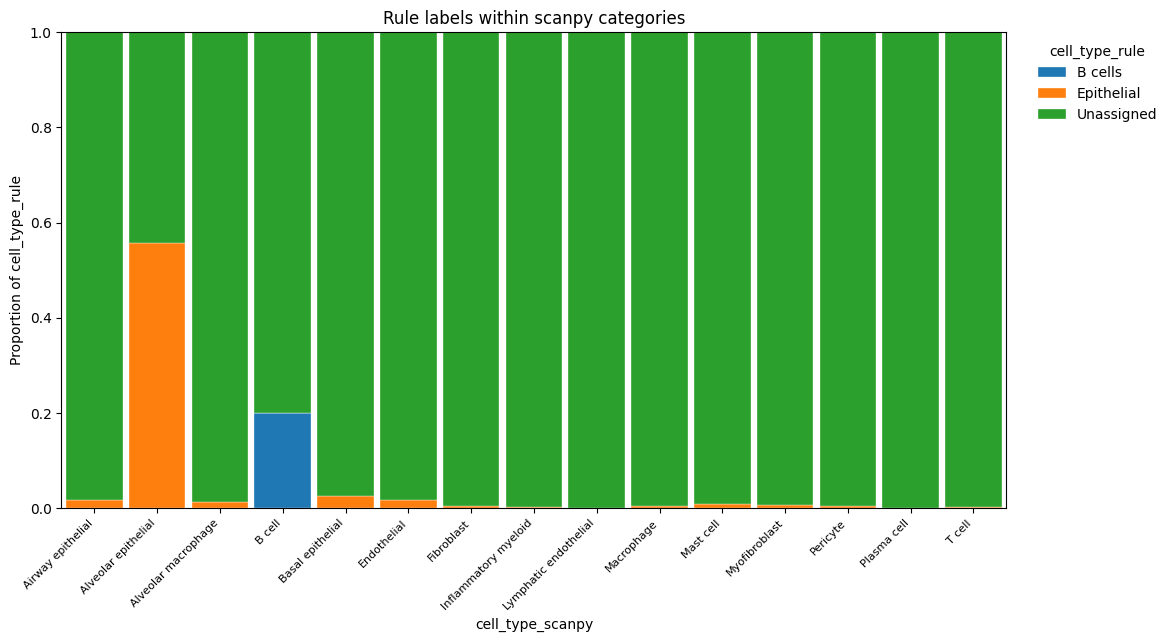

(cell_type_rule          B cells  Epithelial  Unassigned
 cell_type_scanpy                                       
 Airway epithelial      0.000000    0.016487    0.983513
 Alveolar epithelial    0.000000    0.556633    0.443367
 Alveolar macrophage    0.000000    0.013535    0.986465
 B cell                 0.199265    0.000000    0.800735
 Basal epithelial       0.000000    0.026829    0.973171
 Endothelial            0.000000    0.017323    0.982677
 Fibroblast             0.000000    0.005536    0.994464
 Inflammatory myeloid   0.000000    0.002871    0.997129
 Lymphatic endothelial  0.000000    0.000000    1.000000
 Macrophage             0.000000    0.004417    0.995583
 Mast cell              0.000000    0.008377    0.991623
 Myofibroblast          0.000000    0.007188    0.992812
 Pericyte               0.000000    0.004491    0.995509
 Plasma cell            0.000000    0.000000    1.000000
 T cell                 0.000369    0.002953    0.996678,
 <Figure size 1400x700 with 1 

In [ ]:
Utils.custom_barplot(
    adata,
    var_1="cell_type_rule",
    var_2="cell_type_scanpy",
    plot_type="bar",
    cluster_bars=False,
    title=f"Rule labels within scanpy categories",
)

In [26]:
print(f"Reference only: published final_CT vs methods —  ")
print("\nfinal_CT × cell_type_scanpy (top rows):")
display(
    pd.crosstab(
        adata.obs["final_CT"],
        adata.obs["cell_type_scanpy"],
    ).iloc[:10]
)
print("\nfinal_CT × cell_type_rule:")
display(
    pd.crosstab(
        adata.obs["final_CT"],
        adata.obs["cell_type_rule"],
    )
)

Reference only: published final_CT vs methods —  

final_CT × cell_type_scanpy (top rows):


cell_type_scanpy,Airway epithelial,Alveolar epithelial,Alveolar macrophage,B cell,Basal epithelial,Endothelial,Fibroblast,Inflammatory myeloid,Lymphatic endothelial,Macrophage,Mast cell,Myofibroblast,Pericyte,Plasma cell,T cell
final_CT,,,,,,,,,,,,,,,
AT1,20,521,1,0,0,11,4,0,0,2,0,2,0,0,0
AT2,71,1148,7,0,1,12,16,1,0,2,1,3,0,0,3
Activated Fibrotic FBs,0,2,0,2,1,1,252,1,1,2,0,298,14,1,0
Adventitial FBs,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0
Alveolar FBs,45,37,0,17,0,93,2749,16,26,95,16,358,466,11,40
Alveolar Macrophages,0,0,946,0,0,0,0,0,0,43,0,0,0,0,0
Arteriole,0,0,0,0,0,37,0,0,0,0,0,0,0,0,0
B cells,1,0,0,1185,0,0,9,0,0,5,0,0,1,1,26
Basal,22,15,0,0,189,0,4,0,0,0,1,3,2,0,0



final_CT × cell_type_rule:


cell_type_rule,B cells,Epithelial,Unassigned
final_CT,,,
AT1,0,134,427
AT2,0,883,382
Activated Fibrotic FBs,0,4,571
Adventitial FBs,0,0,4
Alveolar FBs,0,40,3929
Alveolar Macrophages,0,13,976
Arteriole,0,0,37
B cells,268,0,960
Basal,0,11,225
